In [1]:
import numpy as np
import pickle
import os
import re 
import json 
import click
import torch
import dnnlib.util_v4 as util
from torch_utils import distributed as dist
from training import toy_training_loop_vfm_noDataGen
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib import colors
from plot_neural import *
from plot_sim_results import * 

import warnings
warnings.filterwarnings('ignore', 'Grad strides do not match bucket view strides') # False warning 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)

In [2]:
colorgrad = "twilight"
plotFolder = "plot"

# 1. Read Data

In [3]:
folder_data = 'data/mc_maze3'
dataset_samples = np.load(folder_data + "/dataset_samples.npz", allow_pickle=True)
data_raw = dataset_samples['samples']
dset_samples = []
for ii in range(len(data_raw)):
    dset_samples.append(np.asarray(data_raw[ii], dtype=np.float64))

In [4]:
# corresponding meta data
train_meta = np.load(folder_data + "/meta_train.npy", allow_pickle=True).tolist()
trial_idx_use = np.array(train_meta['trial_info']['trial_version']) == 0
np.sum(trial_idx_use)

592

# 2. Behavior Data

In [5]:
trial_type_use = np.array(train_meta['trial_info']['trial_type'])[trial_idx_use]
indices = np.where(trial_idx_use)[0]

target_pos_sel = [train_meta['trial_info']['target_pos'][idx] for idx in indices]
target_pos_sel = np.array(target_pos_sel).squeeze(1).astype(np.float32)

hand_pos_sel = [train_meta['behavior']['hand_pos'][idx] for idx in indices]
cursor_pos_sel = [train_meta['behavior']['cursor_pos'][idx] for idx in indices]
eye_pos_sel = [train_meta['behavior']['eye_pos'][idx] for idx in indices]

In [6]:
# np.save(folder_data + "/cov_static_samples.npy", target_pos_sel)

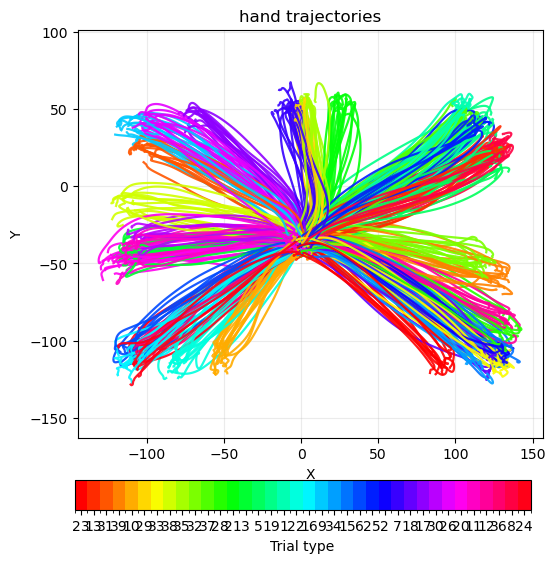

In [8]:
plot_2d_hand_trajectories(hand_pos_sel,
                          trial_indices=None,
                          trial_type_use=trial_type_use,
                          title = "hand trajectories")
plt.savefig(plotFolder + "/1_hand_traj.png")

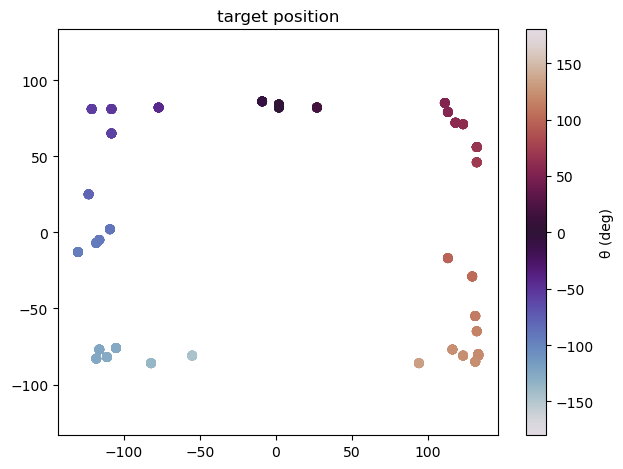

In [9]:
theta_deg = get_theta_deg(target_pos_sel)
theta_wrapped = (theta_deg + 180) % 360 - 180
norm = colors.Normalize(vmin=-180, vmax=180)  # -180→0.0 and 180→1.0 (same color on cyclic cmaps)
plt.scatter(
    target_pos_sel[:, 0], target_pos_sel[:, 1],
    c=theta_wrapped, cmap=colorgrad, norm=norm
)
plt.title('target position')
cbar = plt.colorbar()
cbar.set_label('θ (deg)')
plt.axis('equal'); plt.tight_layout()
plt.savefig(plotFolder + "/2_target_loc.png")

# 3. Brute-force PCA

In [10]:
mean, components, explained_var, explained_var_ratio, transform = pca_stream(dset_samples, n_components=None)

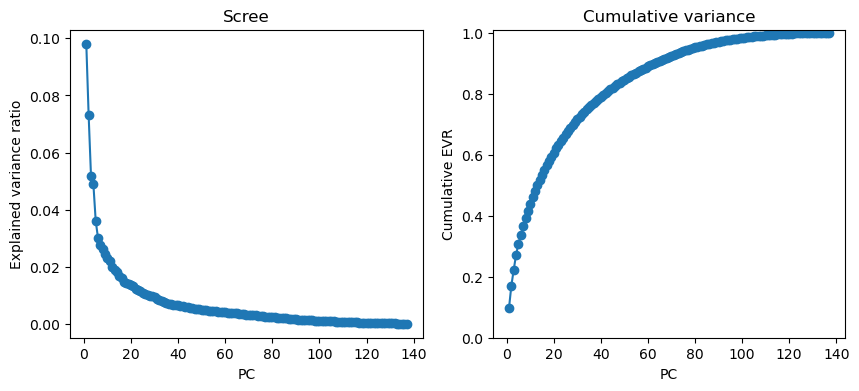

In [11]:
plot_scree(explained_var, explained_var_ratio)
plt.savefig(plotFolder + "/3_pca_scree.png")

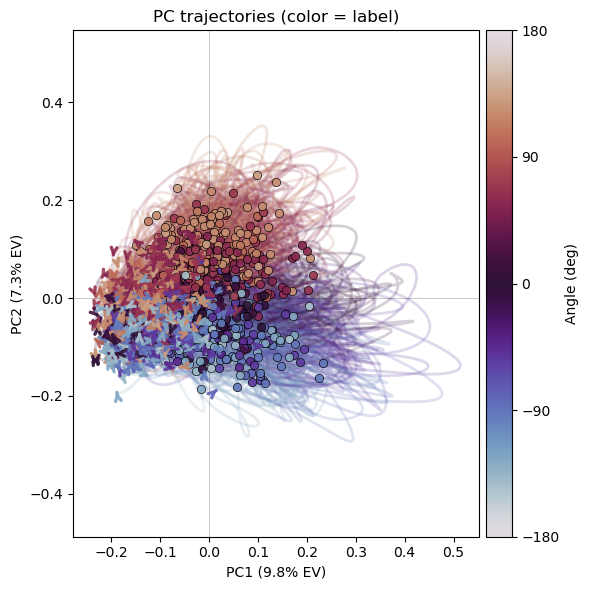

In [12]:
plot_trial_trajectories_gradient_steps(
    transform,
    dset_samples,
    trial_indices=np.arange(len(dset_samples)),   # or any subset
    comps=(0, 1),
    evr=explained_var_ratio,
    linewidth=2.0,
    start_marker_size=36,
    alpha=0.2,
    start_marker_alpha=0.9,
    end_arrow_alpha=0.9,
    fig_w = 6, fig_h = 6,
    labels = theta_deg,
    circmap=colorgrad,
)
plt.savefig(plotFolder + "/4_2d_projec_all.png")

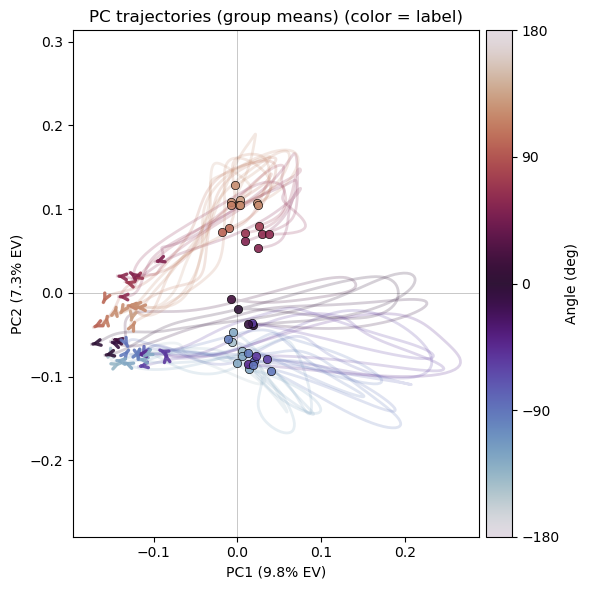

In [13]:
plot_trial_trajectories_gradient_steps(
    transform,
    dset_samples,
    trial_indices=np.arange(len(dset_samples)),   # or any subset
    comps=(0, 1),
    evr=explained_var_ratio,
    linewidth=2.0,
    start_marker_size=36,
    alpha=0.2,
    start_marker_alpha=0.9,
    end_arrow_alpha=0.9,
    fig_w = 6, fig_h = 6,
    labels = theta_deg,
    circmap=colorgrad,
    plot_mean = True
)
plt.savefig(plotFolder + "/5_2d_projec_locMean.png")

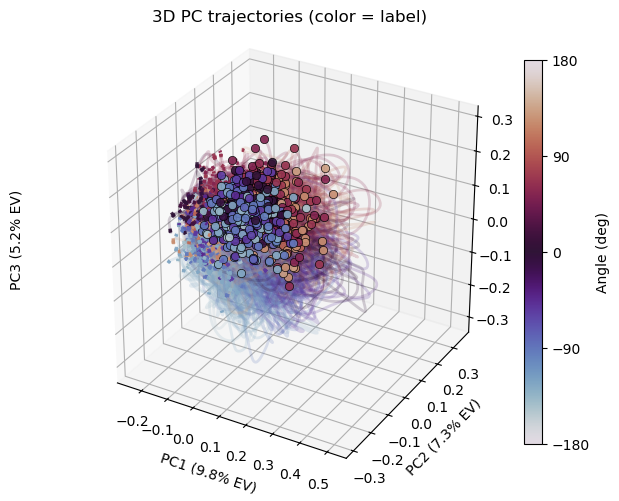

In [14]:
plot_trial_trajectories_gradient_steps_3d(
    transform,
    dset_samples,
    trial_indices=np.arange(len(dset_samples)),  # or choose a subset
    comps=(0, 1, 2),
    evr=explained_var_ratio,
    start_marker_alpha=0.9,
    end_arrow_alpha=0.9,
    alpha = 0.2,
    labels = theta_deg,
    circmap=colorgrad,
)
plt.savefig(plotFolder + "/6_3d_projec_all.png")

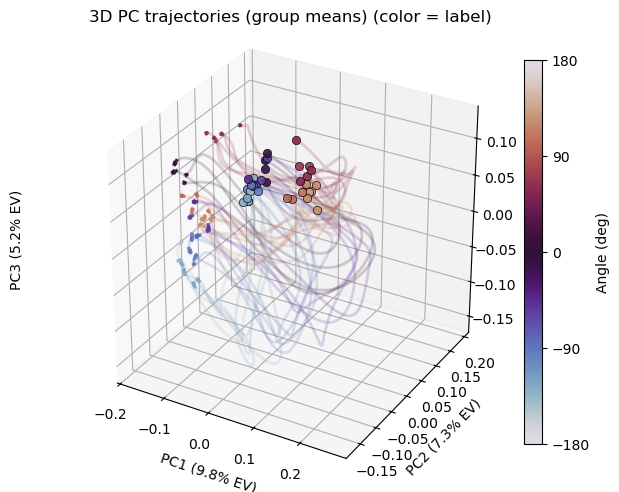

In [15]:
plot_trial_trajectories_gradient_steps_3d(
    transform,
    dset_samples,
    trial_indices=np.arange(len(dset_samples)),  # or choose a subset
    comps=(0, 1, 2),
    evr=explained_var_ratio,
    start_marker_alpha=0.9,
    end_arrow_alpha=0.9,
    alpha = 0.2,
    labels = theta_deg,
    circmap=colorgrad,
    plot_mean = True
)
plt.savefig(plotFolder + "/7_3d_projec_locMean.png")

/home/ganchao/Desktop/Velocity_Flow_Matching-global_new_param_new_pt/plot_neural.py:831: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.02, 0.18 if use_labels else 0.02, 0.98, 0.98])


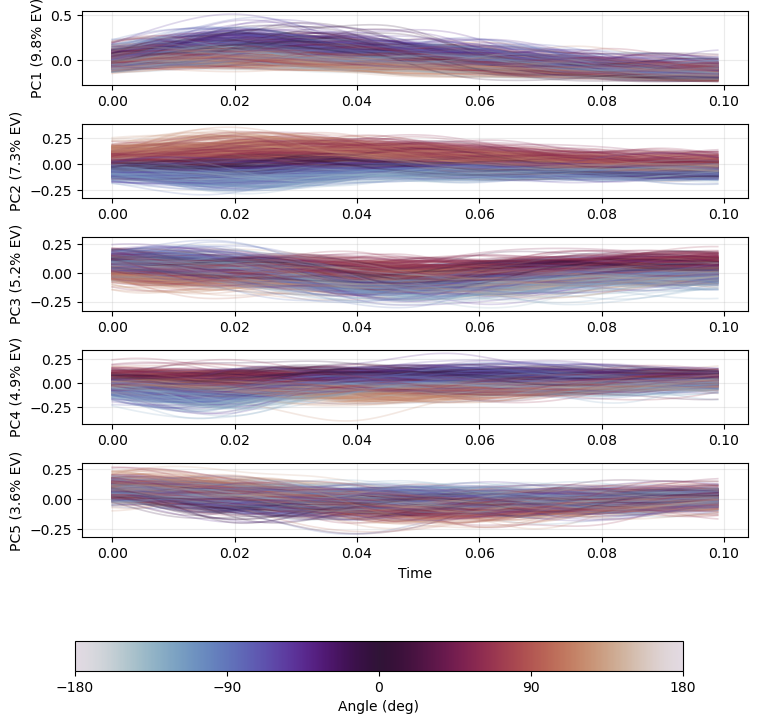

In [16]:
plot_pc_time_series(
    transform, dset_samples,
    pcs=np.arange(5),
    trial_indices=np.arange(len(dset_samples)),
    labels= theta_deg,      # trial_type_use
    evr=explained_var_ratio,
    dt=0.001, # can be None
    alpha = 0.2,
    fig_w= 8,
    fig_h_per = 1.5,
    circmap = colorgrad,
)
plt.savefig(plotFolder + "/8_pc_traj_all.png")

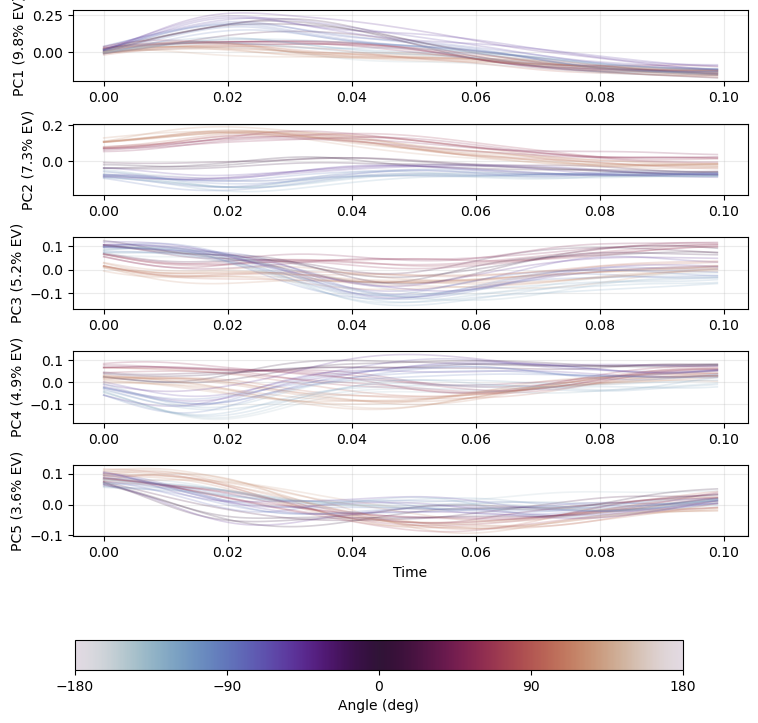

In [17]:
plot_pc_time_series(
    transform, dset_samples,
    pcs=np.arange(5),
    trial_indices=np.arange(len(dset_samples)),
    labels= theta_deg,      # trial_type_use
    evr=explained_var_ratio,
    dt=0.001, # can be None
    alpha = 0.2,
    fig_w= 8,
    fig_h_per = 1.5,
    circmap = colorgrad,
    plot_mean = True
)
plt.savefig(plotFolder + "/9_pc_traj_locMean.png")